## Notebook Summary

Content!

In [1]:
# Imports

import wfdb
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
# Load Data

# Stream single record directly from PhysioNet: PPG and ECG peaks
record = wfdb.rdrecord('s3_walk', 
                        pn_dir='wrist/1.0.0')
annotation = wfdb.rdann('s3_walk', 
                         extension='atr',
                         pn_dir='wrist/1.0.0')

fs = 256
ppg_raw = record.p_signal[:, 1]
accel_x = record.p_signal[:, 5]
accel_y = record.p_signal[:, 6]
accel_z = record.p_signal[:, 7]
r_peaks = annotation.sample

# Combine accel channels
accel_raw = accel_x + accel_y + accel_z

In [3]:
# Pre-processing

# Clip signal length
t1 = 30
t2 = 60
t = np.arange(t1, t2, 1. / fs)
ppg = ppg_raw[fs * t1:fs * t2]
accel = accel_raw[fs * t1:fs * t2]

# Make sure no NaNs
assert sum(np.isnan(ppg)) == 0, "NaNs found in ppg"
assert sum(np.isnan(accel)) == 0, "NaNs found in accel"

# Bandpass filter: 0.5 to 5 Hz (impulse and freq response checked for stability and performance)
order = 4
sos = signal.butter(order, [0.5, 5.0], btype='band', fs=fs, output='sos') 

# Apply BPF to both ppg and accel data
ppg_filt = signal.sosfiltfilt(sos, ppg)
accel_filt = signal.sosfiltfilt(sos, accel)

# Normalize: PPG and accel data in different units on different scales
ppg_norm = (ppg_filt - np.mean(ppg_filt)) / np.std(ppg_filt)
accel_norm = (accel_filt - np.mean(accel_filt)) / np.std(accel_filt)

In [4]:
# Wiener filter

N = len(ppg_norm)
M = 32

R = np.zeros((M, M))
p = np.zeros(M)

for n in range(M, N):
    x_n = accel_norm[n - M:n]
    R += np.outer(x_n, x_n)
    p += ppg_norm[n] * x_n

R /= (N - M)
p /= (N - M)

lambda_reg = 1e-5
w_wiener = np.linalg.solve(R + lambda_reg * np.eye(M), p)

y_wiener = signal.filtfilt(w_wiener, [1.0], accel_norm)
e_wiener = ppg_norm - y_wiener

var_removed = np.var(ppg_norm) - np.var(e_wiener)
pct_removed = 100 * var_removed / np.var(ppg_norm)
print(f"Variance removed: {pct_removed:.2f}%")

Variance removed: 36.09%


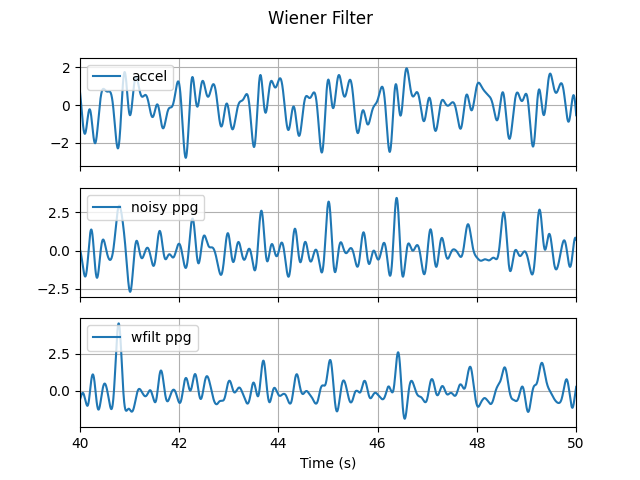

In [8]:
fig, ax = plt.subplots(3,1, sharex=True)
ax[0].plot(t, accel_norm, label='accel')
ax[1].plot(t, ppg_norm, label='noisy ppg')
ax[2].plot(t, e_wiener, label='wfilt ppg')
ax[2].set_xlabel('Time (s)')
fig.suptitle('Wiener Filter')
for axi in ax:
    axi.legend(loc='upper left')
    axi.grid(True)
    axi.set_xlim(40, 50)


## Wiener filter notes:

- 36% variance reduction from noisy ppg to Wiener filtered PPG
- Periodicity in the filtered ppg is almost less visible than in the noisy signal
    - if dominant content in ppg and accel signals overlap in frequency, some unintended removal could have occurred
- Wiener assumes constant noise statistics over entire period (30s), so even if less variance in output signal, adaptive methods will be more suited